# California Housing: Regression and Exploratory Data Analysis

Lecture 1  
Author: Yoshiyuki Arata  
Date: 2026/04/14

## 1 データの準備

このセルでは、数値計算、データ操作、可視化、散布図行列の作成、そして California Housing データセットの取得に必要なライブラリを読み込んでいます。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix
from sklearn.datasets import fetch_california_housing

### データの読み込みと目的変数の分離

このセルでは、California Housing データセットを `DataFrame` として取得し、目的変数 `MedHouseVal` を分離しています。あわせて、上限値に張り付いた外れ値的なサンプルを除外し、説明変数 `X` と目的変数 `y` を作成しています。


In [2]:
# -----------------------------
# 1. Data loading
# -----------------------------
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df = df[df['MedHouseVal'] != 5.000010]

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print(X.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### データセットの説明文の表示

このセルでは、各特徴量の意味やデータセット全体の背景を確認するために、scikit-learn が持つ California Housing データセットの説明文を表示しています。


In [3]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## 2 データの概観確認

このセルでは、先頭行、データの行列サイズ、各列の要約統計量を表示し、変数のスケールや分布の大まかな傾向を確認しています。


In [4]:
# Basic inspection
display(df.head())
print("shape:", df.shape)
display(df.describe().T)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


shape: (19675, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,19675.0,3.676717,1.570272,0.499900,2.526800,3.450000,4.582600,15.000100
HouseAge,19675.0,28.386277,12.509113,1.000000,18.000000,28.000000,37.000000,52.000000
AveRooms,19675.0,5.360901,2.292538,0.846154,4.414568,5.184322,5.970677,132.533333
AveBedrms,19675.0,1.096618,0.451839,0.333333,1.005894,1.048622,1.099338,34.066667
Population,19675.0,1440.812198,1143.648725,3.000000,796.000000,1179.000000,1746.000000,35682.000000
AveOccup,19675.0,3.095189,10.631977,0.692308,2.445486,2.837134,3.304894,1243.333333
Latitude,19675.0,35.651780,2.149802,32.540000,33.930000,34.270000,37.730000,41.950000
Longitude,19675.0,-119.563192,2.006108,-124.350000,-121.760000,-118.500000,-117.990000,-114.310000
MedHouseVal,19675.0,1.924779,0.977115,0.149990,1.166000,1.738000,2.482000,5.000000


### 地理情報の可視化

このセルでは、経度と緯度を用いて地区ごとの位置を散布図で表示し、色で住宅価格の相対的な高低を表しています。
地理的な偏りと価格の関係を把握するための図です。


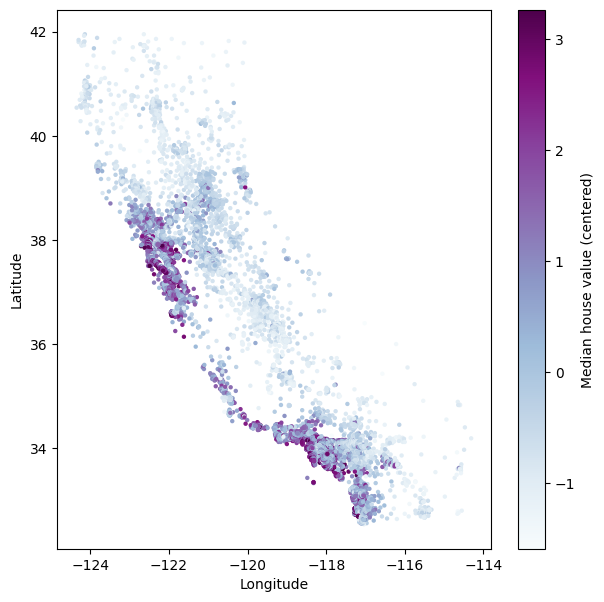

In [5]:
# Geographic visualization
plt.figure(figsize=(7, 7))
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"] - df["MedHouseVal"].median(),
    cmap="BuPu",
    s=10,
    linewidths=0
)
plt.colorbar(label="Median house value (centered)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 3 LightGBM による回帰モデルの学習

このセルでは、データを訓練用とテスト用に分割し、LightGBM 回帰モデルを学習しています。
最後に訓練データとテストデータそれぞれの $R^2$ を表示して、当てはまりを確認しています。

In [6]:
# -----------------------------
# 2. LightGBM regression model
# -----------------------------
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

print("train R^2 =", model.score(X_train, y_train))
print("test  R^2 =", model.score(X_test, y_test))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911
train R^2 = 0.9072396172780637
test  R^2 = 0.829464664147977


### 予測値と実測値の比較

このセルでは、学習済みモデルでテストデータを予測し、実測値と予測値の対応を散布図で可視化しています。赤い破線は完全一致 $y=x$ を表し、点がこの線に近いほど予測精度が高いことを意味します。


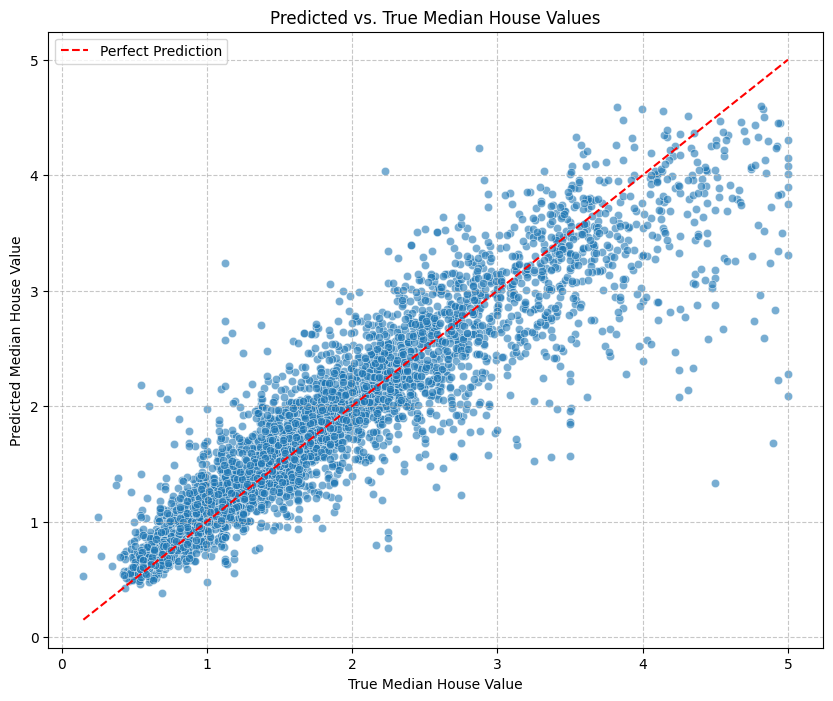

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the already trained model
y_pred = model.predict(X_test)

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'True Values': y_test, 'Predicted Values': y_pred})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='True Values', y='Predicted Values', data=results_df, alpha=0.6)

# Add a perfect prediction line (y=x)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Predicted vs. True Median House Values')
plt.xlabel('True Median House Value')
plt.ylabel('Predicted Median House Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
